In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class StreamingStats:
    """
    Calculates statistics for streaming data for each feature in a 2D array.
    """

    def __init__(self):

        self.n_features = None
        self._n = None
        self._mean = None
        self._M2 = None

    def update_stats(self, X_chunk):

        """
        Updates streaming statistics using a new batch of data.

        Args:
        X_chunk (np.ndarray): A 2D array with of shape (n_samples, n_features) 
        containing data chunk. If previous data chunks have been used to
        update streaming stats, n_features must match the number of features
        of the previous chunks.
        """

        # Exception handling
        if not isinstance(X_chunk, np.ndarray):
            raise TypeError("X_chunk must be a numpy array")
        if np.ndim(X_chunk) != 2:
            raise ValueError("X_chunk must be a 2D array")
        if self.n_features is None:
            self.n_features = X_chunk.shape[1]
            self._n = np.zeros(self.n_features)
            self._mean = np.zeros(self.n_features)
            self._M2 = np.zeros(self.n_features)
        elif self.n_features != X_chunk.shape[1]:
            raise ValueError("X_chunk must have the same number of features as the previous chunks")

        # Determine chunk size
        chunk_size = np.sum(~np.isnan(X_chunk), axis = 0)

        # Calculate batch statistics
        mean_chunk = np.nanmean(X_chunk, axis = 0)
        M2_chunk = np.nansum(((X_chunk - mean_chunk) ** 2), axis = 0)

        # Update stats
        delta = mean_chunk - self._mean
        self._mean += delta * chunk_size / (self._n + chunk_size)
        self._M2 += M2_chunk + delta ** 2 * self._n * chunk_size / (self._n + chunk_size)
        self._n += chunk_size


    @property
    def n(self):
        return self._n


    @property
    def mean(self):
        return self._mean.copy()


    @property
    def var(self):

        """Population variance"""

        self._M2[self._n < 2] = np.nan

        return self._M2 / self._n


    @property
    def std(self):

        """Population standard deviation"""

        return np.sqrt(self.var)

In [ ]:
class StandardScaler(StreamingStats):
    """
    Applies standard scaling to streaming data.
    """

    def __init__(self):

        super().__init__()

    def partial_fit(self, X_chunk):

        """
        Incrementally updates streaming statistics using a new batch of data.

        Args:
        X_chunk (np.ndarray): A 2D array with of shape (n_samples, n_features) 
        containing data chunk. If previous data chunks have been used to
        update streaming stats, n_features must match the number of features
        of the previous chunks.
        """

        self.update_stats(X_chunk)

    def transform(self, X):

        """
        Transforms data using StandardScaler for mean and standard deviation
        computed from streaming data.

        Args:
        X (np.ndarray): A 2D array with of shape (n_samples, n_features) 
        containing data to be scaled. 
        """

        mask = (self.std != 0)
        
        if np.any(mask == 0):
            print("Warning: Some columns have been removed since they have a standard deviation of 0.")
            
        X_filtered = X[:, mask]
        mean_filtered = self.mean[mask]
        std_filtered = self.std[mask]

        return (X_filtered - mean_filtered) / std_filtered

    def fit_transform(self, X):

        """
        Computes mean and standard deviation on streaming data and transforms
        data using StandardScaler.

        Args:
        X (np.ndarray): A 2D array with of shape (n_samples, n_features) 
        containing data to be scaled.
        """

        self.partial_fit(X)
        return self.transform(X)

In [4]:
class Imputer(StreamingStats):

    def __init__(self):

        super().__init__()

    def partial_fit(self, X_chunk):

        """
        Updates streaming statistics using a new batch of data.

        Args:
        X_chunk (np.ndarray): A 2D array with of shape (n_samples, n_features) 
        containing data chunk. If previous data chunks have been used to
        update streaming stats, n_features must match the number of features
        of the previous chunks.
        """

        self.update_stats(X_chunk)

    def transform(self, X):

        """
        Transforms data using Imputer for mean computed from streaming data.

        Args:
        X (np.ndarray): A 2D array with of shape (n_samples, n_features) 
        containing data to be imputed.
        """

        return np.where(np.isnan(X), self.mean, X)


    def fit_transform(self, X):

        """
        Calculates mean on streaming data and transforms data using Imputer.

        Args:
        X (np.ndarray): A 2D array with of shape (n_samples, n_features) 
        containing data to be imputed.
        """

        self.partial_fit(X)
        return self.transform(X)

In [5]:
class OneHotEncoder():

    """
    One hot encoding for streaming data. Maps categorical variables to integer
    encoding. 
    """

    def __init__(self):
        self.encoding = dict()
        self.num_unique = 0
        

    def partial_fit(self, X_chunk):

        """
        Updates encoding using a new batch of data.

        Args:
            X_chunk (np.ndarray): A array containing a chunk of data.
        """

        # Exception handling
        if not isinstance(X_chunk, np.ndarray):
            raise TypeError("X_chunk must be a numpy array")
    
        nan_mask = np.isin(X_chunk, [np.nan, "nan"])
        unique_values = np.unique(X_chunk[~nan_mask])
        new_values = unique_values[~np.isin(unique_values, list(self.encoding.keys()))]
        self.encoding.update(zip(new_values, np.arange(self.num_unique, self.num_unique + len(new_values))))
        self.num_unique += len(new_values)

    def transform(self, X):

        """
        Encoders categorical variables to integer encoding.

        Args:
            X (np.ndarray): A array containing data to be encoded.
        """

        # Exception handling
        if not isinstance(X, np.ndarray):
            raise TypeError("X must be a numpy array")

        # Need to add handle_unknown = "ignore" functionality
        # Need more robust nan functionality for arrays with strings

        encoding_func = np.vectorize(self.encoding.get)
        nan_mask = np.isin(X, [np.nan, "nan"])
        encoded_arr = np.full(X.shape, np.nan)
        encoded_arr[~nan_mask] = encoding_func(X[~nan_mask]).astype(float)
        encoded_arr[nan_mask] = np.nan

        return encoded_arr.astype(int)

    def fit_transform(self, X):

        """
        Encodes categorical variables to integer encoding.

        Args:
            X (np.ndarray): A array containing data to be encoded.
        """

        self.partial_fit(X)
        return self.transform(X)

In [6]:
class StreamingMetrics():

    """
    Calculates binary classification metrics for streaming data.
    """

    def __init__(self):

        super().__init__()

        self.true_pos = 0
        self.true_neg = 0
        self.false_pos = 0
        self.false_neg = 0
        self.n = 0

    def update(self, y_true_chunk, y_pred_chunk):

        """
        Updates metrics using a new batch of data.

        Args:
            y_true_chunk (np.ndarray): A array containing a chunk of true labels.
            y_pred_chunk (np.ndarray): A array containing a chunk of predicted labels.
        """

        # Exception handling
        if not isinstance(y_true_chunk, np.ndarray):
            raise TypeError("y_true_chunk must be a numpy array")
        if not isinstance(y_pred_chunk, np.ndarray):
            raise TypeError("y_pred_chunk must be a numpy array")
        if np.ndim(y_true_chunk) != 1:
            raise ValueError("y_true_chunk must be a 1D array")
        if np.ndim(y_pred_chunk) != 1:
            raise ValueError("y_pred_chunk must be a 1D array")
        if y_true_chunk.shape != y_pred_chunk.shape:
            raise ValueError("y_true_chunk and y_pred_chunk must have the same shape")

        # Update
        self.true_pos += np.sum((y_true_chunk == 1) & (y_pred_chunk == 1))
        self.true_neg += np.sum((y_true_chunk == 0) & (y_pred_chunk == 0))
        self.false_pos += np.sum((y_true_chunk == 0) & (y_pred_chunk == 1))
        self.false_neg += np.sum((y_true_chunk == 1) & (y_pred_chunk == 0))
        self.n += len(y_true_chunk)


    def reset(self):

        """
        Resets metrics.
        """

        self.true_pos = 0
        self.true_neg = 0
        self.false_pos = 0
        self.false_neg = 0
        self.n = 0

    @property
    def accuracy(self):

        if self.n == 0:
            return np.nan

        return (self.true_pos + self.true_neg) / self.n


    @property
    def precision(self):

        if self.true_pos + self.false_pos == 0:
            return np.nan

        return (self.true_pos) / (self.true_pos + self.false_pos)


    @property
    def recall(self):

        if self.true_pos + self.false_neg == 0:
            return np.nan

        return (self.true_pos) / (self.true_pos + self.false_neg)


    @property
    def confusion_matrix(self):
        return np.array([[self.true_pos, self.false_neg], [self.false_pos, self.true_neg]])

In [53]:
class DecisionTreeClassifier:

    """
    Decision tree classifier for streaming data.
    """

    def __init__(self, max_depth = None, min_samples_split = 2, max_features = None, criterion = 'gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.criterion = criterion
        self.tree = None
        self.X = None
        self.y = None

    def fit(self, X, y):

        """
        Fits decision tree to training data.

        Args:
            X (np.ndarray): Training data.
            y (np.ndarray): Training labels.

        """

        self.tree = self._grow_tree(X, y, 0)

    def partial_fit(self, X_chunk, y_chunk):

        """
        Updates decision tree using chunk of training data.

        Args:
            X_chunk (np.ndarray): Training data chunk.
            y_chunk (np.ndarray): Training labels chunk.
        """

        if self.X is None:
            self.X = X_chunk
            self.y = y_chunk

        else:
            self.X = np.concatenate((self.X, X_chunk))
            self.y = np.concatenate((self.y, y_chunk))

        self.fit(self.X, self.y)

    def predict(self, X):

        """
        Predicts labels from data using fitted decision tree.

        Args:
            X (np.ndarray): Data to predict labels for.

        Returns:
            np.ndarray: Predicted labels.
        """

        return np.array([self._predict_one(x, self.tree) for x in X])

    def _compute_impurity(self, y):

        """
        Computes impurity of a node (either gini impurity or entropy).

        Args:
            y (np.ndarray): Node labels.

        Returns:
            float: Impurity of node.
        """

        probs = y / np.sum(y)

        if self.criterion == 'gini':
            return (1 - np.sum(probs ** 2))
        elif self.criterion == 'entropy':
            probs = probs[probs > 0]
            return -np.sum(probs * np.log2(probs))

    def _impurity_gain(self, parent_counts, left_counts, right_counts):

        """
        Computes impurity gain of a split.

        Args:
            parent_counts (np.ndarray): Parent node labels.
            left_counts (np.ndarray): Left child node labels.
            right_counts (np.ndarray): Right child node labels.

        Returns:
            float: Impurity gain of split.
        """

        parent_total = np.sum(parent_counts)
        left_total = np.sum(left_counts)
        right_total = np.sum(right_counts)

        if left_total == 0 or right_total == 0:
            return 0

        parent_impurity = self._compute_impurity(parent_counts)
        left_impurity = self._compute_impurity(left_counts)
        right_impurity = self._compute_impurity(right_counts)

        weighted_child = (left_total / parent_total) * left_impurity + (right_total / parent_total) * right_impurity
        impurity_gain = parent_impurity - weighted_child

        return impurity_gain


    def _find_best_split(self, X, y):

        """
        Finds best split for a node.

        Args:
            X (np.ndarray): Node data.
            y (np.ndarray): Node labels.

        Returns:
            tuple: Best feature and threshold for split.
        """

        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        best_gain = 0
        best_feature = None
        best_threshold = None
        parent_counts = np.bincount(y, minlength=n_classes)

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                left_indices = X[:, feature] <= threshold
                right_indices = X[:, feature] > threshold

                left_counts = np.bincount(y[left_indices], minlength = n_classes)
                right_counts = np.bincount(y[right_indices], minlength = n_classes)

                if not np.any(left_indices) or not np.any(right_indices):
                    continue

                gain = self._impurity_gain(parent_counts, left_counts, right_counts)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _grow_tree(self, X, y, depth):

        """
        Recursively grows decision tree.

        Args:
            X (np.ndarray): Node data.
            y (np.ndarray): Node labels.
            depth (int): Depth of node in tree.


        """

        values, counts = np.unique(y, return_counts=True)
        prediction = values[np.argmax(counts)]

        if len(values) == 1 or len(y) < self.min_samples_split:
            return prediction

        if self.max_depth is not None and depth >= self.max_depth:
              return prediction

        feature, threshold = self._find_best_split(X, y)

        if feature is None:
            return prediction

        left = X[:, feature] <= threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self._grow_tree(X[left], y[left], depth + 1),
            "right": self._grow_tree(X[~left], y[~left], depth + 1),
        }

    def _predict_one(self, x, node):

        """
        Predicts label for a single data point.

        Args:
            x (np.ndarray): Data point.
            node (dict): Node in tree.

        Returns:
            int: Predicted label.
        """

        if not isinstance(node, dict):
            return node

        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        return self._predict_one(x, node["right"])


In [8]:
class EnsembleClassifier(DecisionTreeClassifier):
    """
    Ensemble method using bagging (i.e. bootstrap aggregating).
    """

    def __init__(self, n_estimators = 100):
        super().__init__()
        self.n_estimators = n_estimators
        self.trees = np.full(n_estimators, None, dtype=object)
        self.X = None
        self.y = None

    def fit(self, X, y):

        """
        Fits ensemble of decision trees to training data.

        Args:
            X (np.ndarray): Training data.
            y (np.ndarray): Training labels.
        """

        # Exception handling
        if not isinstance(X, np.ndarray):
            raise TypeError("X must be a NumPy array")
        if not isinstance(y, np.ndarray):
            raise TypeError("y must be a NumPy array")
        if np.ndim(X) != 2:
            raise ValueError("X must be a 2D array")
        if np.ndim(y) != 1:
            raise ValueError("y must be 1D array")
        if len(X) != len(y):
            raise ValueError("X and y must have the same length")

        n_samples = X.shape[0]

        for i in range(self.n_estimators):
            
            # Generate a new bootstrap sample for each tree
            indices = np.random.choice(n_samples, size = n_samples, replace = True)
            X_bootstrap = X[indices, :]
            y_bootstrap = y[indices]

            tree = DecisionTreeClassifier()
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees[i] = tree

        self.X = X
        self.y = y

    def partial_fit(self, X_chunk, y_chunk):

        """
        Updates ensemble of decision trees using chunk of training data.

        Args:
            X_chunk (np.ndarray): Training data chunk.
            y_chunk (np.ndarray): Training labels chunk.
        """
        
        if self.X is None:
            self.X = X_chunk
            self.y = y_chunk

        else:
            self.X = np.concatenate((self.X, X_chunk))
            self.y = np.concatenate((self.y, y_chunk))

        self.fit(self.X, self.y)

    def predict(self, X):

        """
        Predicts labels from data using fitted ensemble of decision trees.

        Args:
            X (np.ndarray): Data to predict labels for.

        Returns:
            np.ndarray: Predicted labels.
        """

        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.array([np.bincount(predictions[:, i]).argmax() for i in range(X.shape[0])])


In [111]:
class Pipeline():

    """
    Provides a pipeline for preprocessing, model fitting and prediction.
    """

    def __init__(self, pipe):
        super().__init__()
        self.pipe = pipe
    
    def partial_fit(self, X_chunk, y_chunk):

        """
        Applies preprocessing procedure and fits model for a chunk of data.

        Args:
            X_chunk (np.ndarray): Data chunk.
            y_chunk (np.ndarray): Labels chunk.
        """

        # Exception handling
        if not isinstance(X_chunk, np.ndarray):
            raise TypeError("X_chunk must be a NumPy array")
        if not isinstance(y_chunk, np.ndarray):
            raise TypeError("y_chunk must be a NumPy array")
        if np.ndim(X_chunk) != 2:
            raise ValueError("X_chunk must be a 2D array")
        if np.ndim(y_chunk) != 1:
            raise ValueError("y_chunk must be 1D array")

        # Perform steps in pipeline    

        for name, operation in self.pipe:

            if name == "model":
                operation.partial_fit(X_chunk, y_chunk)
            elif name == "scaler" or name == "imputer":
                X_chunk = operation.fit_transform(X_chunk)
            elif name == "encoder":
                y_chunk = operation.fit_transform(y_chunk)

    def predict(self, X):

        """
        Predicts labels from data using fitted pipeline.

        Args:
            X (np.ndarray): Data to predict labels for.

        Returns:
            np.ndarray: Predicted labels.
        """

        # Exception handling
        if not isinstance(X, np.ndarray):
            raise TypeError("X must be a NumPy array")
        if np.ndim(X) != 2:
            raise ValueError("X must be a 2D array")

        # Predict using fitted pipeline
        for name, operation in self.pipe:
            if name == "model":
                return operation.predict(X)
            elif name == "scaler" or name == "imputer":
                X = operation.transform(X)

In [110]:
class StreamTrainer(StreamingMetrics):

    """
    Applies pipeline to stream of data and updates classification metrics.
    """

    def __init__(self, pipeline):
        super().__init__()
        self.pipeline = pipeline
        self.logs = None

    def fit_chunk(self, X_chunk, y_chunk):

        """
        Updates pipeline using chunk of data.

        Args:
            X_chunk (np.ndarray): Data chunk.
            y_chunk (np.ndarray): Labels chunk.
        """

        self.pipeline.partial_fit(X_chunk, y_chunk)

    def score_chunk(self, X_chunk, y_chunk):

        """
        Updates metrics for a chunk of data.

        Args:
            X_chunk (np.ndarray): Data chunk.
            y_chunk (np.ndarray): Labels chunk.
        """

        y_pred_chunk = self.pipeline.predict(X_chunk)

        for name, operation in self.pipeline.pipe:

            if name == "encoder":
                y_chunk = operation.fit_transform(y_chunk)

        self.update(y_chunk, y_pred_chunk)

        if self.logs is None:
            self.logs = np.array([[self.accuracy, self.precision, self.recall]])
        else:
            self.logs = np.vstack((self.logs, np.array([[self.accuracy, self.precision, self.recall]])))

    def reset_logs(self):

        """
        Resets logs.
        """
        self.logs = None

In [55]:
def plot_metric_over_time(metric_values, title, ylabel, save_path = None):
    """
    Plots the value of a metric as chunks of data arrive.

    Args:
        metric_values (np.array): 1D array of metric values.
        title (str): Title of the plot.
        ylabel (str): Label of the y-axis.
    """

    # Exception handling
    if not isinstance(metric_values, np.ndarray):
        raise TypeError("metric_values must be a numpy array")
    if np.ndim(metric_values) != 1:
        raise ValueError("metric_values must be a 1D array")
    if len(metric_values) == 0:
        raise ValueError("metric_values must not be empty")

    # Produce plot
    x = np.arange(len(metric_values))
    plt.plot(x, metric_values)
    plt.xlabel("Number of Chunks")
    plt.ylabel(ylabel)
    plt.title(title)

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

In [45]:
def compare_models(metric1, metric2, labels, title, ylabel, save_path = None):
    """
    Produces plot that compares the performance of two models
    according to a given metric as chunks of data arrive.

    Args:
        metric1 (np.array): 1D array of metric values for the first model.
        metric2 (np.array): 1D array of metric values for the second model.
        labels (list): List of labels for the two models.
        title (str): Title of the plot.
        ylabel (str): Label of the y-axis.
    """

    # Exception handling
    if not isinstance(metric1, np.ndarray) or not isinstance(metric2, np.ndarray):
        raise TypeError("metric_values must be a numpy array")
    if np.ndim(metric1) != 1 or np.ndim(metric2) != 1:
        raise ValueError("metric_values must be a 1D array")
    if len(metric1) != len(metric2):
        raise ValueError("metric_values must have the same length")
    if len(metric1) == 0 or len(metric2) == 0:
        raise ValueError("metric_values must not be empty")
    if not isinstance(labels, list):
        raise TypeError("labels must be a list")
    if len(labels) != 2:
        raise ValueError("labels must have length 2")


    # Produce plot
    x = np.arange(len(metric1))
    plt.plot(x, metric1)
    plt.plot(x, metric2)
    plt.xlabel("Number of Chunks")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(labels)

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

In [56]:
def plot_predictions_vs_ground_truth(y_true, y_pred, num_classes, save_path = None):
    """
    Produces a grouped histogram showing the frequency of each class
    in the ground truth and predicted labels.

    Args:
        y_true (np.array): 1D array of ground truth labels.
        y_pred (np.array): 1D array of predicted labels.
        num_classes (int): Number of classes
    """

    # Exception handling
    if not isinstance(y_true, np.ndarray) or not isinstance(y_pred, np.ndarray):
        raise TypeError("y_true and y_pred must be numpy arrays")
    if not isinstance(num_classes, int):
        raise TypeError("num_classes must be an integer")
    if np.ndim(y_true) != 1 or np.ndim(y_pred) != 1:
        raise ValueError("y_true and y_pred must be 1D arrays")
    

    # Produce plot
    bin_edges = np.arange(-0.5, num_classes + 1.5, 1)
    plt.hist([y_true, y_pred], bins = bin_edges, rwidth = 0.8)
    plt.xticks(np.arange(num_classes))
    plt.xlim([-0.75, num_classes - 0.25])
    plt.legend(["Ground Truth", "Predictions"])
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title("Ground Truth vs Predictions")

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

Demo

In [109]:
def split_data_2_chunks(X, y, num_chunks):
    """
    Splits data into num_chunks chunks.

    Args:
        X (np.ndarray): Data.
        y (np.ndarray): Labels.
        num_chunks (int): Number of chunks.

    Returns:
        X_chunks (list): List of X chunks.
        y_chunks (list): List of y chunks.
    """

    # Exception handling
    if not isinstance(X, np.ndarray) or not isinstance(y, np.ndarray):
        raise TypeError("X and y must be numpy arrays")

    return np.array_split(X, num_chunks, axis = 0), np.array_split(y, num_chunks)

In [96]:
def train_test_split(X, y, test_size = 0.2):
    """
    Splits data into training and testing sets.

    Args:
        X (np.ndarray): Data.
        y (np.ndarray): Labels.
        test_size (float): Proportion of data to use for testing.
    """

    # Exception handling
    if not isinstance(test_size, float):
        raise TypeError("test_size must be a float")
    if test_size < 0 or test_size > 1:
        raise ValueError("test_size must be between 0 and 1")

    # Set seed for reproducibility
    np.random.seed(42)

    # Generate shuffled row indices
    num_rows = X.shape[0]
    indices = np.arange(num_rows)
    np.random.shuffle(indices)

    # Split data into training and testing sets
    split_index = int(num_rows * (1 - test_size))
    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    X_train = X[train_indices, :]
    y_train = y[train_indices]
    X_test = X[test_indices, :]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test

In [112]:
# Set seed for reproducibility
np.random.seed(42)

# Load iris dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'

iris_data = np.genfromtxt(url, delimiter=',', dtype=str)

In [113]:
# Take a look at iris dataset

print(f"Iris data shape: {iris_data.shape}")

print(f"\nFirst 10 rows: \n{iris_data[:10, :]}")

labels, counts = np.unique(iris_data[:, -1], return_counts = True)

print(f"\nLabels: {labels}, Counts: {counts}")

Iris data shape: (150, 5)

First 10 rows: 
[['5.1' '3.5' '1.4' '0.2' 'Iris-setosa']
 ['4.9' '3.0' '1.4' '0.2' 'Iris-setosa']
 ['4.7' '3.2' '1.3' '0.2' 'Iris-setosa']
 ['4.6' '3.1' '1.5' '0.2' 'Iris-setosa']
 ['5.0' '3.6' '1.4' '0.2' 'Iris-setosa']
 ['5.4' '3.9' '1.7' '0.4' 'Iris-setosa']
 ['4.6' '3.4' '1.4' '0.3' 'Iris-setosa']
 ['5.0' '3.4' '1.5' '0.2' 'Iris-setosa']
 ['4.4' '2.9' '1.4' '0.2' 'Iris-setosa']
 ['4.9' '3.1' '1.5' '0.1' 'Iris-setosa']]

Labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica'], Counts: [50 50 50]


In [114]:
# Define pipeline
pipeline1 = Pipeline([
    ("encoder", OneHotEncoder()),
    ("imputer", Imputer()),
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier())
])

pipeline2 = Pipeline([
    ("encoder", OneHotEncoder()),
    ("imputer", Imputer()),
    ("scaler", StandardScaler()),
    ("model", EnsembleClassifier())
])

# Setup steam trainers
trainer1 = StreamTrainer(pipeline1)
trainer2 = StreamTrainer(pipeline2)

# Turn into binary classification problem
iris_data = iris_data[iris_data[:, -1] != 'Iris-setosa']

# Extract X and y arrays
X = iris_data[:, :-1].astype(float)
y = iris_data[:, -1]

# Split data into training and tests sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [115]:
# Look for class imbalance between training a test datasets

train_classes, train_counts = np.unique(y_train, return_counts = True)
test_classes, test_counts = np.unique(y_test, return_counts = True)

print(f"Training Set | Size: {len(y_train)}, Classes : {train_classes}, Counts : {train_counts}")
print(f"Testing Set | Size: {len(y_test)}, Classes : {test_classes}, Counts : {test_counts}")

Training Set | Size: 80, Classes : ['Iris-versicolor' 'Iris-virginica'], Counts : [42 38]
Testing Set | Size: 20, Classes : ['Iris-versicolor' 'Iris-virginica'], Counts : [ 8 12]


In [116]:
# Split data into streaming chunks
X_train_chunks, y_train_chunks = split_data_2_chunks(X_train, y_train, 4)
X_test_chunks, y_test_chunks = split_data_2_chunks(X_test, y_test, 4)

# Train and test model for each chunk
for i in range(len(X_train_chunks)):
    trainer1.fit_chunk(X_train_chunks[i], y_train_chunks[i])
    trainer1.score_chunk(X_test_chunks[i], y_test_chunks[i])

    trainer2.fit_chunk(X_train_chunks[i], y_train_chunks[i])
    trainer2.score_chunk(X_test_chunks[i], y_test_chunks[i])

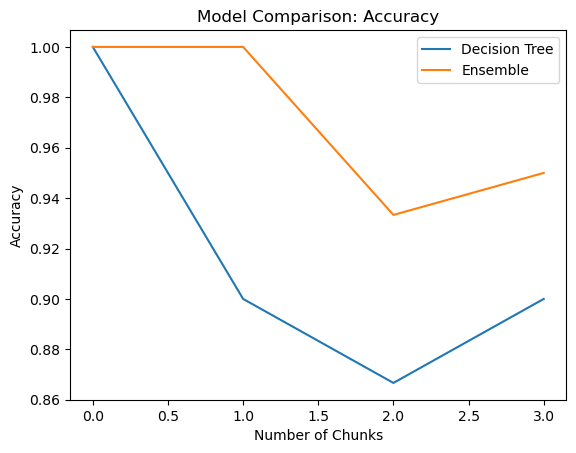

In [103]:
compare_models(trainer1.logs[:, 0], trainer2.logs[:, 0], ["Decision Tree", "Ensemble"], "Model Comparison: Accuracy", "Accuracy", save_path = "demo_accuracy.png")

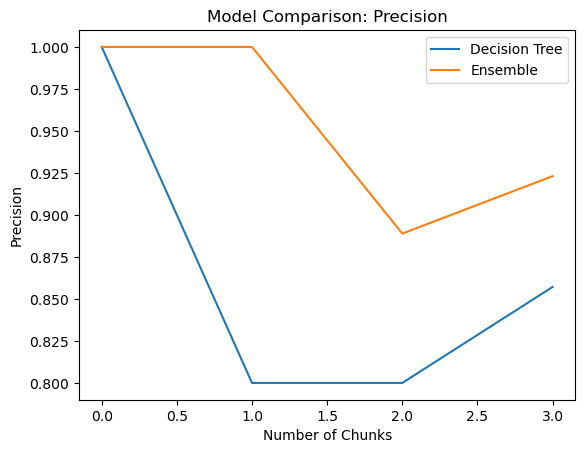

In [104]:
compare_models(trainer1.logs[:, 1], trainer2.logs[:, 1], ["Decision Tree", "Ensemble"], "Model Comparison: Precision", "Precision", save_path = "demo_precision.png")

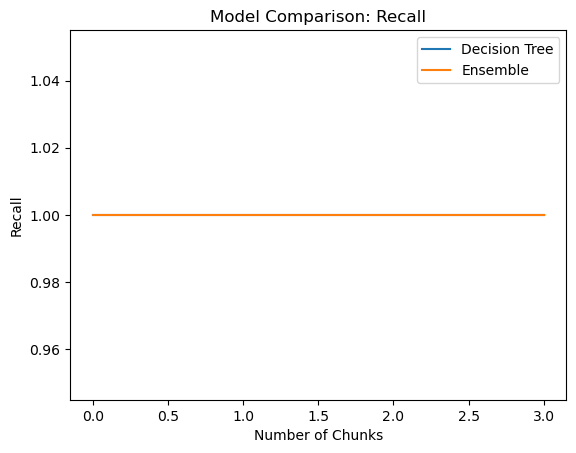

In [105]:
compare_models(trainer1.logs[:, 2], trainer2.logs[:, 2], ["Decision Tree", "Ensemble"], "Model Comparison: Recall", "Recall", save_path = "demo_recall.png")

In [106]:
conf_mat_form = np.array([['TP', 'FN'], ['FP', 'TN']])
conf_mat_decision_tree = trainer1.confusion_matrix
conf_mat_ensemble = trainer2.confusion_matrix

print(f"Confusion Matrix Form: \n{conf_mat_form}")
print(f"\nDecision Tree Confusion Matrix: \n{conf_mat_decision_tree}")
print(f"\nEnsemble Confusion Matrix: \n{conf_mat_ensemble}")

Confusion Matrix Form: 
[['TP' 'FN']
 ['FP' 'TN']]

Decision Tree Confusion Matrix: 
[[12  0]
 [ 2  6]]

Ensemble Confusion Matrix: 
[[12  0]
 [ 1  7]]
